**Business Problem :** Predict Sales Price for each house from the Ames Housing datset (expanded version of the often cited Boston Housing dataset)

**Statistical Problem:** Which features impact to the price of a house the most and drive buying decisions. Need to analyze numeric features like area, distance from road along with categorical features of a housing project like neighbourhood etc to determine the right set of creative features determining the sales price of a house.

**What are we Predicting**: Sales Price of each house.

**Is this Regression or Classification**: Its a regression problem since the target variables is a numeric feature.

**Metric Used by Kaggle:** Submissions are evaluated on Root-Mean-Squared-Error (RMSE) between the logarithm of the predicted value and the logarithm of the observed sales price. (Taking logs means that errors in predicting expensive houses and cheap houses will affect the result equally.)

In [1]:
import os
import sys
project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
sys.path.insert(0, project_root)
print(f"Working From: {project_root}")

Working From: c:\Users\ChandrG\ML-Project-House-Prices


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from src import config

print("Config Values:")
for k, v in vars(config).items():
    if not k.startswith("__"):
        print(f"{k}: {v}")

Config Values:
os: <module 'os' (frozen)>
PROJECT_ROOT: c:\Users\ChandrG\ML-Project-House-Prices
DATA_DIR: c:\Users\ChandrG\ML-Project-House-Prices\data
RAW_DATA_DIR: c:\Users\ChandrG\ML-Project-House-Prices\data\raw
PROCESSED_DATA_DIR: c:\Users\ChandrG\ML-Project-House-Prices\data\processed
MODELS_DIR: c:\Users\ChandrG\ML-Project-House-Prices\models
RESULTS_DIR: c:\Users\ChandrG\ML-Project-House-Prices\results
NOTEBOOKS_DIR: c:\Users\ChandrG\ML-Project-House-Prices\notebooks
TRAIN_DATA_PATH: c:\Users\ChandrG\ML-Project-House-Prices\data\raw\train.csv
TEST_DATA_PATH: c:\Users\ChandrG\ML-Project-House-Prices\data\raw\test.csv
DATA_DESCRIPTION_PATH: c:\Users\ChandrG\ML-Project-House-Prices\data\raw\data_description.txt
SAMPLE_SUBMISSION_PATH: c:\Users\ChandrG\ML-Project-House-Prices\data\raw\sample_submission.csv


## ***Section 1 : Data Exploration & Transformation Strategies***

### 1.0 What I Should Have Established First Before Looking at Feature Correlations

My earlier flow moved too quickly into correlations between predictors. That is not the best statistical starting point for this competition.

The first quantity I should understand is the target itself, `SalePrice`, because the Kaggle metric is not ordinary RMSE on raw prices. It is RMSE on the logarithm of prices. That changes the geometry of the learning problem.

If I model price directly, the model is penalized in absolute dollar units. If I model `log(SalePrice)`, the model is penalized much more like a relative or percentage error. This is usually more appropriate for housing prices because a `$20,000` error has very different meaning for a cheap home versus a luxury home.

Mathematically, the competition score behaves like:

$$
\mathrm{RMSE}_{\log} = \sqrt{\frac{1}{n}\sum_{i=1}^{n}(\log(\hat{y}_i) - \log(y_i))^2}
$$

For small errors, a log difference has the interpretation:

$$
\log(\hat{y}) - \log(y) = \log\left(\frac{\hat{y}}{y}\right)
$$

So the model is effectively judged on multiplicative error rather than raw additive error. That is why the first real question should have been:

1. Is `SalePrice` skewed?
2. Does `log1p(SalePrice)` become closer to symmetric?
3. Should all validation and baseline modeling be done on the log-transformed target?

This is not a cosmetic transform. It changes the optimization landscape, reduces the dominance of extreme high-price homes, and often makes linear models fit much better.

An easy intuition is this:

- Predicting `$100,000` instead of `$120,000` is a noticeable error.
- Predicting `$480,000` instead of `$500,000` is much less serious, even though both mistakes are `$20,000`.

A raw-price loss treats those two errors as identical. A log-price loss does not. That is why my notebook should reason in the transformed target space very early.

In [3]:
df_train = pd.read_csv(config.TRAIN_DATA_PATH)
print(f"Shape of df_train: {df_train.shape}")
print("\nInfo of df_train:")
df_train.info()
print("\nDescription of df_train:")
df_train.describe().T

Shape of df_train: (1460, 81)

Info of df_train:
<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual   

,count,mean,std,min,25%,50%,75%,max
Id,1460.0,730.500000,421.610009,1.0,365.75,730.5,1095.25,1460.0
MSSubClass,1460.0,56.897260,42.300571,20.0,20.00,50.0,70.00,190.0
LotFrontage,1201.0,70.049958,24.284752,21.0,59.00,69.0,80.00,313.0
LotArea,1460.0,10516.828082,9981.264932,1300.0,7553.50,9478.5,11601.50,215245.0
OverallQual,1460.0,6.099315,1.382997,1.0,5.00,6.0,7.00,10.0
OverallCond,1460.0,5.575342,1.112799,1.0,5.00,5.0,6.00,9.0
YearBuilt,1460.0,1971.267808,30.202904,1872.0,1954.00,1973.0,2000.00,2010.0
YearRemodAdd,1460.0,1984.865753,20.645407,1950.0,1967.00,1994.0,2004.00,2010.0
MasVnrArea,1452.0,103.685262,181.066207,0.0,0.00,0.0,166.00,1600.0
BsmtFinSF1,1460.0,443.639726,456.098091,0.0,0.00,383.5,712.25,5644.0


Skewness Test Result: SkewtestResult(statistic=np.float64(20.184466954847846), pvalue=np.float64(1.340658503782391e-90))
Original SalePrice Skewness: 1.88


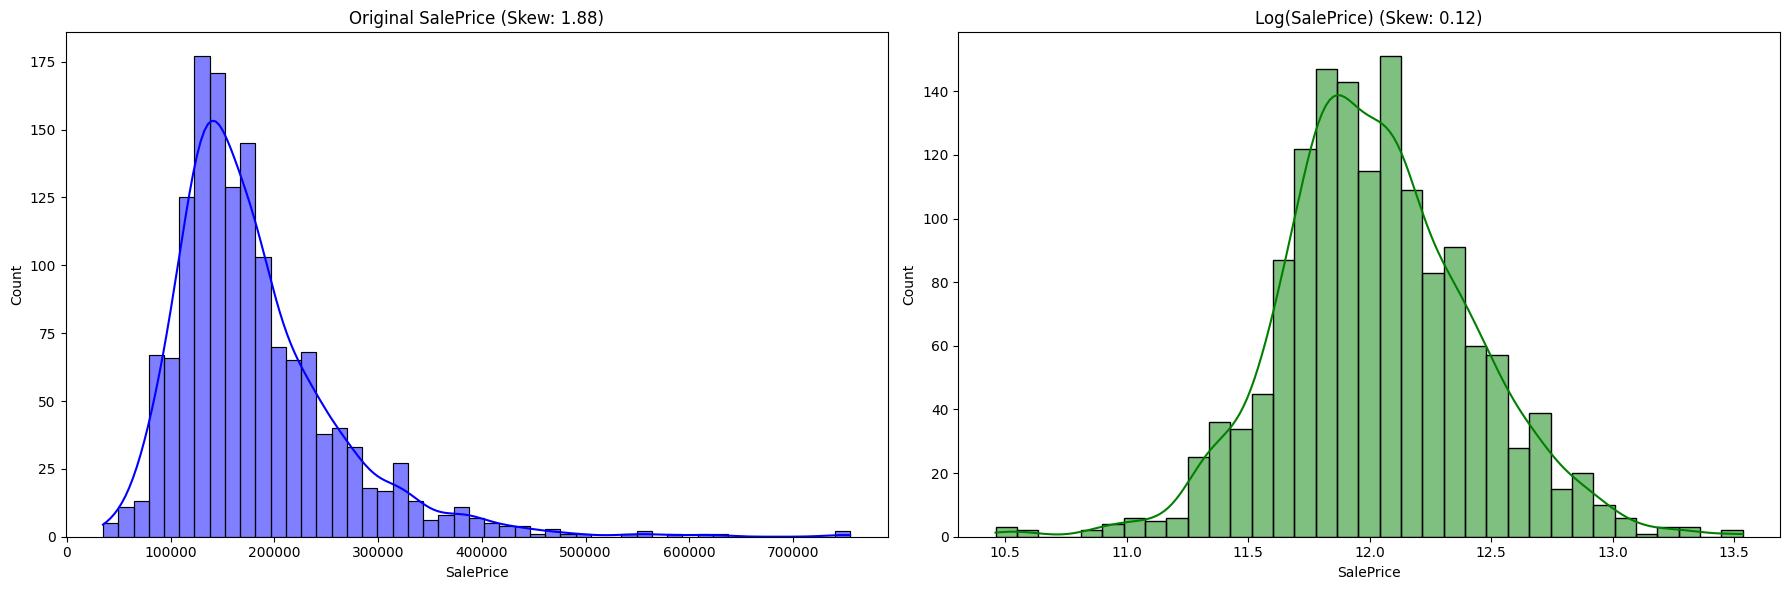

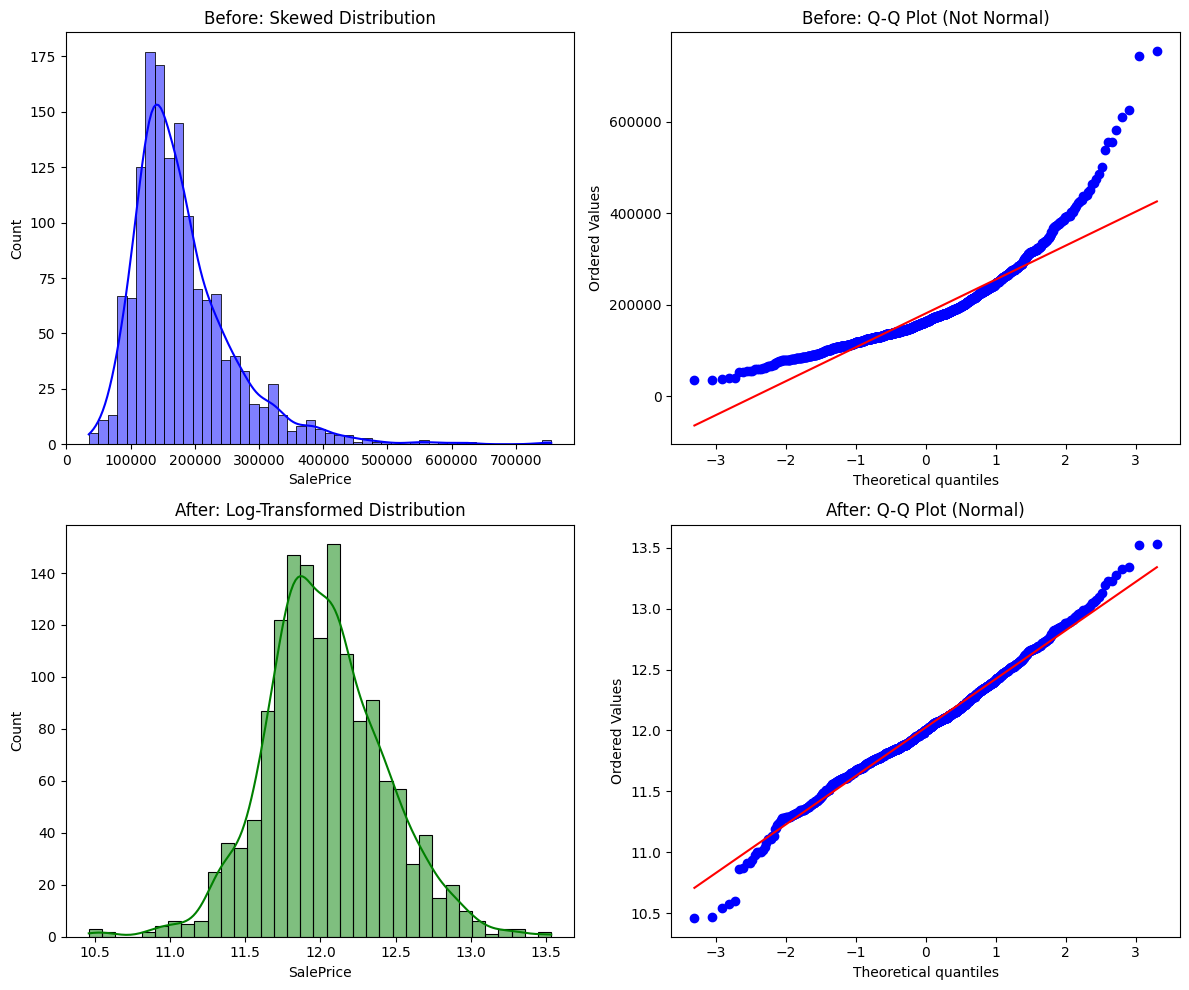

In [22]:
from scipy import stats

res = stats.skewtest(df_train['SalePrice'])
print(f"Skewness Test Result: {res}")
# Its a hypothesis test.
# What it is: This is a Z-score (the statistic) and a p-value.
# What it means: It calculates the probability that your data came from a perfectly normal distribution by chance.
# Statistic (Z-score): Tells you how many standard deviations away your data is from "normal." A value like 20+ means your data is extremely far from normal.
# p-value: If this is very low (e.g., 0.00e+00), it means the "Null Hypothesis" (that your data is normal) is rejected.
# Usage: This is used in formal statistics to prove that a dataset is definitely not normally distributed.

# stats.skew (The Descriptive Metric)
# What it is: This is the Skewness Coefficient.
# What it means: It measures the shape of your data.
# 0: Perfect symmetry (Bell curve).
# 1.88: (What you likely see for SalePrice) This tells you the tail on the right is very long.
# Usage: This is what we use in Machine Learning to decide if we need a Log Transformation.
original_skew = stats.skew(df_train['SalePrice'])
print(f"Original SalePrice Skewness: {original_skew:.2f}")

# 2. Visualize the distribution
plt.figure(figsize=(18, 6))

plt.subplot(1, 2, 1)
sns.histplot(df_train['SalePrice'], kde=True, color='blue')
plt.title(f"Original SalePrice (Skew: {original_skew:.2f})")

# If Skew > 1: Your data is "highly skewed." You must use a log transformation for linear models to work properly.
# If Skew is between -0.5 and 0.5: Your data is "fairly symmetrical." You might not need a transformation.

# 3. Apply Log Transformation and check again
plt.subplot(1, 2, 2)
log_sale_price = np.log(df_train['SalePrice'])
sns.histplot(log_sale_price, kde=True, color='green')
plt.title(f"Log(SalePrice) (Skew: {stats.skew(log_sale_price):.2f})")

plt.tight_layout()
plt.show()

# Sometimes a number doesn't tell the whole story. Data scientists use Q-Q (Quantile-Quantile) Plots because they show exactly where the data deviates from normal.
# Is it only the extreme outliers (the very expensive mansions)?
# Is it the middle of the data?
# Why this matters: If only the outliers are the problem, you might just remove them. If the whole curve is wrong, you need a Log transform.
# Create a Q-Q plot
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# BEFORE TRANSFORMATION
sns.histplot(df_train['SalePrice'], kde=True, ax=axes[0, 0], color='blue')
axes[0, 0].set_title("Before: Skewed Distribution")
stats.probplot(df_train['SalePrice'], plot=axes[0, 1])
axes[0, 1].set_title("Before: Q-Q Plot (Not Normal)")

# AFTER TRANSFORMATION
log_prices = np.log1p(df_train['SalePrice'])
sns.histplot(log_prices, kde=True, ax=axes[1, 0], color='green')
axes[1, 0].set_title("After: Log-Transformed Distribution")
stats.probplot(log_prices, plot=axes[1, 1])
axes[1, 1].set_title("After: Q-Q Plot (Normal)")

plt.tight_layout()

**Interpretation & To-Do for Skewness Test 1.0**
- Insights : Log trnasformation does help solving the data skewnes in SalePrice and corrects its symmetry. We also, did the Q-Q plot test to verify that post ransformation we get a near normal distribution of SalePrice effective for outlier prices.
- To Do : Log transform SalePrice feature in Transformation section. 

## 1.1. Correlation Analysis

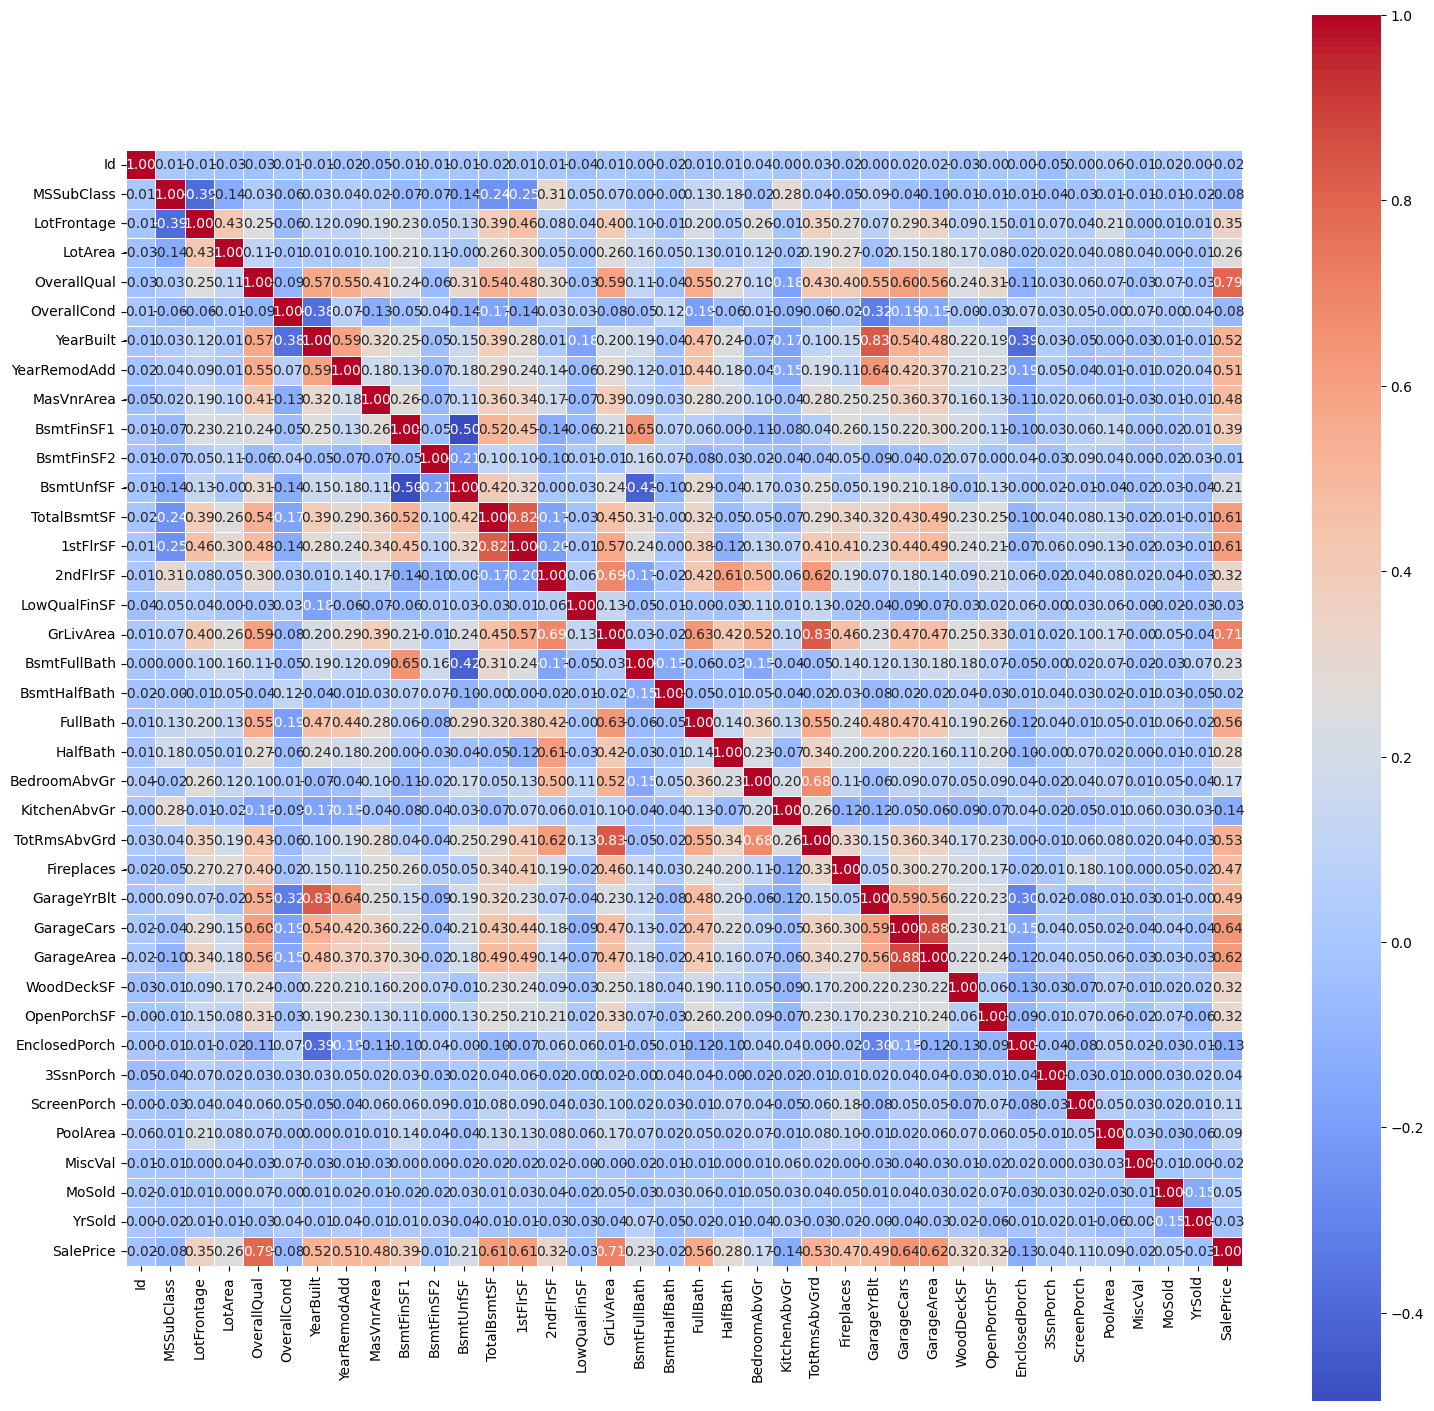


Strongly Correlated Feature Pairs (Correlation > 0.8):
GarageArea    GarageCars      0.882475
GarageCars    GarageArea      0.882475
GarageYrBlt   YearBuilt       0.825667
YearBuilt     GarageYrBlt     0.825667
TotRmsAbvGrd  GrLivArea       0.825489
GrLivArea     TotRmsAbvGrd    0.825489
1stFlrSF      TotalBsmtSF     0.819530
TotalBsmtSF   1stFlrSF        0.819530
dtype: float64


In [4]:
# Check correlations between features
corr_matrix = df_train.select_dtypes(include=[np.number]).corr()

plt.figure(figsize=(18, 18))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, square=True)
plt.show()

# Find out feature pairs with high correlation (above 0.8 but less than 1 to avoid self-correlation) and can be considered for removal due to multicollinearity
corr_pairs = corr_matrix.unstack().sort_values(ascending=False)
strong_corr_pairs = corr_pairs[(corr_pairs > 0.8) & (corr_pairs < 1)]
print("\nStrongly Correlated Feature Pairs (Correlation > 0.8):")
print(strong_corr_pairs)

**Interpretation & To-Do for Numeric Features 1.1**

1. `SalePrice` is strongly associated with variables such as `OverallQual` and `GrLivArea`, but I should not treat correlation as proof of causation. Correlation tells me how variables move together in this dataset; it does not prove that one variable is the true economic driver.
2. High correlation between two predictors does not automatically mean one must be dropped. That conclusion is too aggressive.
3. Multicollinearity mainly matters for coefficient stability and interpretability in linear models. It is much less of a direct problem for tree-based models.
4. Therefore, the correct decision rule is not "drop the weaker of two correlated features immediately." The correct rule is: keep a hypothesis list, then validate drops or engineered replacements using cross-validated model performance.

**Reasoning About the Strongly Correlated Pairs**

1. `GarageArea` and `GarageCars`

These two variables measure related but not identical concepts. `GarageCars` captures capacity, while `GarageArea` captures physical size. They may overlap, but they are not semantically interchangeable. A small model with regularization may decide how much each matters. A better inference is: this pair is redundant enough to monitor, not automatically prune.

2. `YearBuilt` and `GarageYrBlt`

Here the redundancy is more plausible because the garage is often built with the house. In addition, `GarageYrBlt` has missing values. This is a more defensible candidate for dropping, but even here the rigorous justification should be: it is highly redundant, partially incomplete, and should be validated by performance rather than removed by correlation alone.

3. `TotRmsAbvGrd` and `GrLivArea`

`GrLivArea` is a continuous size measure, while `TotRmsAbvGrd` is a coarse count. The continuous measurement often contains more information, but room count may still add layout information that area alone misses. The correct inference is that `GrLivArea` may dominate, not that `TotRmsAbvGrd` is necessarily useless.

4. `1stFlrSF` and `TotalBsmtSF`

These should not be viewed as a simple redundancy pair. Their correlation may arise because larger homes tend to have both larger first floors and larger basements. That is not the same as saying they duplicate each other. A better next step is to test whether an engineered size variable such as total square footage gives a cleaner signal.

**The Mathematical Mindset :**

If two predictors `x_1` and `x_2` are highly correlated, then in an ordinary least squares model,

$$
\hat{\beta} = (X^T X)^{-1} X^T y
$$

the matrix $X^T X$ can become poorly conditioned. That makes coefficient estimates unstable. Small changes in the data can cause large changes in the fitted coefficients.

But that does not mean prediction must become poor. It means the decomposition of importance across correlated variables becomes unstable.

So the right question is not:

"Which variable wins the correlation contest?"

The right questions are:

1. Does keeping both variables improve validation performance?
2. Does replacing them with one engineered feature improve performance?
3. Does regularization shrink one of them naturally?
4. Do I care more about interpretability or predictive accuracy?

That is the statistical discipline I should use going forward.

In [8]:
# Check for categorical columns
# Hint: select categorical dtypes explicitly so the notebook remains stable across pandas versions.
cat_cols = df_train.select_dtypes(include=['object', 'string', 'category']).columns
print(f"\nCategorical Columns: {cat_cols}")

# Create a summary table for categorical columns
cat_summary = pd.DataFrame({
    'Column': cat_cols,
    'Unique Values': [df_train[col].nunique() for col in cat_cols],
    'Top Value': [df_train[col].mode()[0] for col in cat_cols],
    'Frequency of Top Value': [df_train[col].value_counts().iloc[0] for col in cat_cols],
    'Percentage of Top Value': [df_train[col].value_counts(normalize=True).iloc[0] * 100 for col in cat_cols]
})

display(cat_summary.sort_values(by='Percentage of Top Value', ascending=False))


Categorical Columns: Index(['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities',
       'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2',
       'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st',
       'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation',
       'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
       'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual',
       'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual',
       'GarageCond', 'PavedDrive', 'PoolQC', 'Fence', 'MiscFeature',
       'SaleType', 'SaleCondition'],
      dtype='str')


,Column,Unique Values,Top Value,Frequency of Top Value,Percentage of Top Value
5,Utilities,2,AllPub,1459,99.931507
1,Street,2,Pave,1454,99.589041
10,Condition2,8,Norm,1445,98.972603
14,RoofMatl,8,CompShg,1434,98.219178
26,Heating,6,GasA,1428,97.808219
36,GarageCond,5,TA,1326,96.156635
35,GarageQual,5,TA,1311,95.068891
7,LandSlope,3,Gtl,1382,94.657534
28,CentralAir,2,Y,1365,93.493151
31,Functional,7,Typ,1360,93.150685


## 1.2. Missing Data Analysis

In [6]:
# Check for missing values
print("\nMissing values in df_train:")
df_missing = df_train.filter(items=[col for col in df_train.columns if df_train[col].isnull().any()]).isnull().sum()
df_missing = df_missing.to_frame(name='missing_count')
df_missing['missing_prcnt'] = df_missing['missing_count'] / len(df_train) * 100

# 2. Calculate correlation with SalePrice (numeric only)
corrmat = df_train.corr(numeric_only=True)
corr_with_target = corrmat['SalePrice'].abs().sort_values(ascending=False)

df_missing_summary = df_missing.join(corr_with_target.to_frame(name='corr_with_SalePrice'), how='left')


print(df_missing_summary.sort_values(by='missing_prcnt', ascending=False))


Missing values in df_train:
              missing_count  missing_prcnt  corr_with_SalePrice
PoolQC                 1453      99.520548                  NaN
MiscFeature            1406      96.301370                  NaN
Alley                  1369      93.767123                  NaN
Fence                  1179      80.753425                  NaN
MasVnrType              872      59.726027                  NaN
FireplaceQu             690      47.260274                  NaN
LotFrontage             259      17.739726             0.351799
GarageType               81       5.547945                  NaN
GarageYrBlt              81       5.547945             0.486362
GarageFinish             81       5.547945                  NaN
GarageQual               81       5.547945                  NaN
GarageCond               81       5.547945                  NaN
BsmtExposure             38       2.602740                  NaN
BsmtFinType2             38       2.602740                  NaN
BsmtQual   

**Interpretation & To-Do for Missingness in Dataset 1.2**

My earlier list of imputation rules had several good instincts, but I should separate the *type* of missingness before deciding the treatment.

In statistics, I should think about missingness through the conditional mechanism:

$$
P(M = 1 \mid X, Y)
$$

where $M = 1$ means a value is missing.

A useful practical distinction for this project is:

1. **Structural missingness**: the value is absent because the house truly does not have that feature.
2. **Measurement missingness**: the value should exist conceptually, but it was not recorded.

Examples help:

- If `PoolQC` is missing for almost every house, that usually means most houses have no pool. That is structural absence, not random data loss.
- If `LotFrontage` is missing, the house still has frontage in reality. The value is simply unrecorded. That is a genuine imputation problem.

This distinction matters because the information content is different.

If I replace structural absence with a generic statistical estimate, I destroy signal. A missing `PoolQC` is informative because it often implies "no pool." In contrast, a missing `LotFrontage` should be estimated from related variables because the quantity exists but was not measured.

So the proper mental model is:

- Structural absence should often be encoded as an explicit category such as `NA = No Garage`, `NA = No Basement`, or `NA = No Pool`.
- Measurement missingness should often be imputed using central tendency, neighborhood structure, or feature-conditioned rules.
- Some variables deserve both an imputed value and a missing-indicator feature if I believe the missingness itself carries signal.

A clean mathematical intuition is that imputation is an approximation to the conditional expectation:

$$
\hat{x}_{\text{missing}} \approx \mathbb{E}[X \mid Z]
$$

where $Z$ contains related observed variables. For example, imputing `LotFrontage` from bins of `LotArea` or from neighborhood-level structure is an attempt to estimate a conditional expectation rather than insert an arbitrary constant.

That is a much stronger way to think than simply saying, "fill with median because median is robust." The real question is: *median conditional on what structure?*

**To-Do Missing-Value Strategy and the Logic Behind It**

1. `LotFrontage`

This should be treated as a measurement-missing variable, not as structural absence. A grouped median based on a land-size proxy such as `LotArea` bins is reasonable because frontage and lot size are related. Even better is to test whether grouping by neighborhood adds more local structure.

2. `Alley`

Filling with `NA = No Alley Access` is logically sound because the missingness is usually structural.

3. `MasVnrType`

Filling with `NA = None` is reasonable if the missingness corresponds to no masonry veneer rather than a recording gap.

4. `MasVnrArea`

The correct reasoning is conditional. If veneer type is effectively `None`, then area should be `0`. Otherwise, I should use a grouped estimate informed by similar homes rather than a single global fill.

5. Basement quality and type variables: `BsmtQual`, `BsmtCond`, `BsmtExposure`, `BsmtFinType1`, `BsmtFinType2`

These should be handled as a family, not one variable at a time in isolation. If the home has no basement, then the appropriate category is structural `NA = No Basement`. If a basement exists but a component is unrecorded, then I should be more careful because that is no longer structural absence.

6. `Electrical`

Mode imputation is acceptable here because missingness is very small and the variable is categorical. The logic is pragmatic rather than deeply structural.

7. `FireplaceQu`

This is typically structural absence: no fireplace implies no fireplace quality rating.

8. Garage variables: `GarageType`, `GarageFinish`, `GarageQual`, `GarageCond`

These are also best handled together. If the house has no garage, then `NA = No Garage` preserves meaning better than a statistical guess.

9. `GarageYrBlt`

My earlier explanation was too simplistic. I should not drop it *only* because it is correlated with `YearBuilt`. A better justification would be: it is redundant with house age information, it has missingness, and in many homes the garage construction year adds limited incremental signal. Whether to drop it should still be validated empirically.

10. `PoolQC`, `Fence`, `MiscFeature`

These are strong candidates for structural absence encoding because the very high missingness rates are themselves evidence that many houses do not have these amenities.

**What the Broader Statistical Lesson Is**

Imputation is not a cleaning ritual. It is a modeling decision about the data-generating process.

If I misunderstand the mechanism behind missingness, then the model learns from distorted inputs. In other words, bad imputation is a form of label-preserving noise injection into the feature matrix.

A good way to summarize the logic is:

$$
\text{Treatment of missingness} = f(\text{domain meaning}, \text{missingness mechanism}, \text{model family}, \text{validation score})
$$

So the correct workflow is:

1. Identify whether the missingness is structural or statistical.
2. Choose a semantically consistent fill rule.
3. Consider adding a missing-indicator when the absence itself may carry information.
4. Validate the decision through model performance rather than intuition alone.

### 1.2 What I Should Build Next

I should not jump to feature-dropping or advanced ensembles yet. The next milestone is to convert this exploratory reasoning into a disciplined baseline experiment.

**What I should do next in the notebook**

1. Study the distribution of `SalePrice` and `log1p(SalePrice)` side by side.
2. Write down why the log target is the correct training target for this competition.
3. Create a train-validation split before making modeling claims.
4. Build a baseline preprocessing workflow for numeric and categorical columns.
5. Train the simplest linear baseline first.
6. Evaluate validation RMSE in log space.
7. Inspect residuals to see what the baseline is still missing.
8. Only after that compare Ridge, Lasso, and Elastic Net.

**Hints for my coding section, without writing the code for myself**

1. Create `X` by removing the target column.
2. Create two versions of the target mentally: raw target and log-transformed target. The model comparison should be done on the log target.
3. Separate numeric and categorical columns explicitly.
4. For the first baseline, keep preprocessing simple:
   - numeric: robust central imputation
   - categorical: categorical imputation plus one-hot encoding
5. Start with an unregularized linear model only to create a reference point.
6. Use cross-validation or a held-out validation set, but make sure the metric matches the competition logic.

**What I should expect conceptually**

If the log transform is appropriate, then:

- residual spread should become more stable,
- the model should stop over-focusing on the most expensive homes,
- and regularized linear models should become much easier to compare fairly.

**The Mathematical Goal of the Next Section**

I am about to move from descriptive analysis to supervised learning. At that stage, my notebook should formally define:

$$
X \in \mathbb{R}^{n \times p}, \quad y = \log(1 + \mathrm{SalePrice})
$$

and then learn a function

$$
\hat{f}: X \rightarrow y
$$

that minimizes out-of-sample error.

That is the exact point where the project becomes machine learning rather than exploratory analysis.

**A final discipline note to myself**

I should stop treating each notebook insight as automatically true. Every feature choice, drop rule, and imputation rule is only a hypothesis until validation supports it.

In [30]:
# Check for duplicates
duplicate_count = df_train.duplicated().sum()
print(f"\nNumber of duplicate rows in df_train: {duplicate_count}")

# Check for extreme values in SalePrice using the IQR rule
Q1 = df_train['SalePrice'].quantile(0.25)
Q3 = df_train['SalePrice'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers = df_train[(df_train['SalePrice'] < lower_bound) | (df_train['SalePrice'] > upper_bound)]
print(f"\nNumber of outliers in SalePrice: {outliers.shape[0]}")

# This is not class imbalance in the classification sense.
# For regression, this check is better interpreted as target-tail coverage:
# how much of the dataset lies in lower, middle, and upper price ranges.
price_bins = [0, 100000, 200000, 300000, 400000, 500000, np.inf]
price_labels = ['0-100k', '100k-200k', '200k-300k', '300k-400k', '400k-500k', '500k+']
df_train_check = df_train.copy()
df_train_check['Price_Range'] = pd.cut(df_train['SalePrice'], bins=price_bins, labels=price_labels)

price_range_counts = df_train_check['Price_Range'].value_counts().sort_index()
price_range_share = df_train_check['Price_Range'].value_counts(normalize=True).sort_index().mul(100)

print(f"\nDistribution of price ranges:\n{price_range_counts}")
print(f"\nPercentage share by price range:\n{price_range_share.round(2)}")


Number of duplicate rows in df_train: 0

Number of outliers in SalePrice: 61

Distribution of price ranges:
Price_Range
0-100k       123
100k-200k    910
200k-300k    312
300k-400k     87
400k-500k     19
500k+          9
Name: count, dtype: int64

Percentage share by price range:
Price_Range
0-100k        8.42
100k-200k    62.33
200k-300k    21.37
300k-400k     5.96
400k-500k     1.30
500k+         0.62
Name: proportion, dtype: float64


## 1.3 Data Quality Checks and Target-Tail Coverage

A regression target can be skewed or have a long upper tail, but that is not the same thing as class imbalance.

In classification, imbalance means the label space is discrete and one class is severely underrepresented, for example:

- 95% class `0`
- 5% class `1`

That creates a decision problem where accuracy can become misleading.

In regression, `SalePrice` is continuous. There are no classes to balance. What I care about instead is:

1. skewness of the target,
2. presence of extreme values,
3. whether the expensive tail is thin enough to make the model unstable,
4. whether my loss function overreacts to rare expensive homes.

That is exactly why I handled the problem with a log transform rather than with a balancing method.

The mathematical reason is that squared-error loss on raw prices,

$$
\mathrm{MSE} = \frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2,
$$

penalizes mistakes on expensive homes much more heavily in absolute terms. When the target has a long right tail, a few large prices can dominate the optimization.

By moving to

$$
y^{(\log)} = \log(1 + y),
$$

I compress the scale of large values. That reduces the leverage of the upper tail without artificially "balancing" the dataset.

So the correct interpretation of the cell below is not "checking target imbalance." It is checking whether the target distribution has adequate coverage across price ranges and whether the upper tail is thin enough that I should be cautious when interpreting validation results.

If the expensive tail were extremely sparse and very important to the business objective, then I could later consider:

- weighted loss,
- stratified binning for validation only,
- quantile analysis of errors,
- or separate diagnostics for luxury homes.

But for this Kaggle objective, the first principled correction is still the log transform, not a balancing procedure.

In [ ]:
# Split data into train and validation sets in the same target space as the Kaggle metric
from sklearn.model_selection import train_test_split

X = df_train.drop(columns=['SalePrice']).copy()
y_raw = df_train['SalePrice'].copy()
y_log = np.log1p(y_raw)

X_train, X_val, y_train, y_val = train_test_split(
    X, y_log, test_size=0.2, random_state=42
    )

print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_val shape: {X_val.shape}, y_val shape: {y_val.shape}")
print(f"Training target mean (log space): {y_train.mean():.4f}")
print(f"Validation target mean (log space): {y_val.mean():.4f}")

X_train shape: (1168, 80), y_train shape: (1168,)
X_val shape: (292, 80), y_val shape: (292,)
Training target mean (log space): 12.0307
Validation target mean (log space): 11.9977


### 2.1 Why This Split Code Looks the Way It Does

This cell is doing three conceptually important things.

**First, it separates features from target.**

I create:

$$
X = \text{all columns except SalePrice}, \qquad y = \mathrm{SalePrice}
$$

That expresses the supervised-learning problem in standard notation: predictors on one side, target on the other.

**Second, it transforms the target before splitting.**

I then define:

$$
y_{\log} = \log(1 + y)
$$

The `+1` is included by `log1p`. It is numerically stable and is a standard safe practice. In this dataset the prices are positive, so both `log(y)` and `log(1+y)` are valid, but `log1p` is the cleaner habit.

Why do this *before* thinking about the model? Because the target space defines what error means. Once I say the model will learn `y_log`, every later quantity, prediction, residual, and RMSE must be interpreted in that same transformed space.

**Third, it creates a holdout validation set.**

The call to `train_test_split` creates two disjoint subsets:

- training data, used to estimate model parameters,
- validation data, used to approximate out-of-sample performance.

Mathematically, if the model is trained on a function class $\mathcal{F}$, then I want to estimate not just training loss,

$$
\frac{1}{n_{train}}\sum_{i \in train}(y_i - \hat{f}(x_i))^2,
$$

but generalization error on unseen data,

$$
\frac{1}{n_{val}}\sum_{i \in val}(y_i - \hat{f}(x_i))^2.
$$

That is the reason for the split. Without it, a model can look impressive simply because it memorized quirks of the training set.

**Why I print the target means**

The final two print statements are a quick distribution sanity check. If the average target in the train and validation sets is wildly different, then the split may have created two differently distributed subsets. Here they are close, which is a reassuring sign that the split is reasonable.

**Code-reading intuition**

- `X` means "what the model gets to see."
- `y_raw` means "the original business quantity."
- `y_log` means "the target space in which the model is actually trained and scored."
- `X_train, X_val, y_train, y_val` means "inputs and targets, each split into fit-data and check-data."

## Section 2 : Baseline Modeling Workflow

At this point, the notebook moves from descriptive statistics to supervised learning.

The baseline must be intentionally simple. Its job is not to win the competition. Its job is to establish a trustworthy reference point. Once I have that reference, every later improvement can be judged against something concrete rather than intuition.

For this project, the correct baseline setup is:

1. train on the log-transformed target,
2. preprocess numeric and categorical features separately,
3. fit an ordinary linear regression model,
4. evaluate validation RMSE in log space,
5. inspect residual behavior before deciding on more complex models.

If the baseline is built correctly, then Ridge, Lasso, Elastic Net, and feature engineering all become meaningful comparisons rather than disconnected experiments.

**How Section 2 is organized**

- split the problem into inputs and target,
- define the target in the same space as the competition metric,
- build a preprocessing map from raw table columns to model-ready numeric arrays,
- fit the simplest linear model,
- measure error and study residuals.

This is the first place in the notebook where every line of code is serving a formal modeling purpose rather than an exploratory one.

### 2.2 How the Preprocessing and Baseline Model Work

This cell is building a full mapping from a raw pandas table to the linear algebra object that linear regression actually needs.

A linear model does not understand text categories or missing values directly. It expects a numeric design matrix. In notation, I want to construct a transformed matrix

$$
\tilde{X} = T(X),
$$

where $T$ is the preprocessing operator.

That operator is assembled in stages.

**Step 1: split columns by data type**

The notebook separates:

- numeric features,
- categorical features.

This matters because the mathematical treatment is different.

**Step 2: impute numeric columns**

For numeric features, I use median imputation. Intuitively, the median is a robust center. Unlike the mean, it is less distorted by large houses or rare extreme values.

If a feature has missing values, this step replaces them with a central estimate:

$$
\tilde{x}_{ij} = \mathrm{median}(x_{\cdot j}) \quad \text{when } x_{ij} \text{ is missing.}
$$

This is a simple baseline, not the final best strategy.

**Step 3: impute and encode categorical columns**

Categorical variables cannot be fed directly into linear regression because text labels such as `Neighborhood = NAmes` or `ExterQual = Gd` are symbols, not numeric coordinates.

So the pipeline does two things:

1. fills missing categories using the most frequent observed value,
2. expands each category into one-hot indicator columns.

If a variable has $k$ categories, one-hot encoding maps it into a binary vector in $\{0,1\}^k$ where one position is active and the rest are zero.

For example, if `Street` has categories `{Grvl, Pave}`, then:

$$
\text{Pave} \mapsto [0, 1], \qquad \text{Grvl} \mapsto [1, 0].
$$

That turns symbolic values into coordinates the model can use.

**Step 4: combine both transformations with ColumnTransformer**

This object applies one transformation to numeric columns and another to categorical columns, then concatenates the outputs. Conceptually:

$$
T(X) = [T_{num}(X_{num}) \; | \; T_{cat}(X_{cat})].
$$

This is the design matrix that the regression model actually sees.

**Step 5: fit ordinary linear regression**

After preprocessing, the model estimates coefficients by solving the least-squares problem

$$
\min_{\beta_0, \beta} \sum_{i=1}^{n}(y_i - \beta_0 - \tilde{x}_i^T \beta)^2.
$$

The fitted coefficients tell the model how to combine all transformed features into a prediction in log-price space.

**Why use a Pipeline**

The `Pipeline` guarantees that the exact same preprocessing learned from the training set is applied to validation data before prediction. This avoids leakage and keeps the modeling workflow coherent.

**Code-reading intuition**

- `numeric_features` and `categorical_features` define which columns go down which branch.
- `numeric_transformer` says how to clean numeric variables.
- `categorical_transformer` says how to clean and encode categorical variables.
- `baseline_preprocessor` merges both branches.
- `baseline_model` means "preprocess first, regress second" as one reusable object.

In [28]:
# Build a preprocessing pipeline and fit the simplest defensible regression baseline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

numeric_features = X_train.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X_train.select_dtypes(include=['object', 'string', 'category']).columns.tolist()

numeric_transformer = Pipeline(
    steps=[('imputer', SimpleImputer(strategy='median'))]
    )

categorical_transformer = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore'))
    ]
    )

baseline_preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
    )

baseline_model = Pipeline(
    steps=[
        ('preprocessor', baseline_preprocessor),
        ('regressor', LinearRegression())
    ]
    )

baseline_model.fit(X_train, y_train)
print('Baseline linear regression model fitted successfully.')
print(f'Numeric features: {len(numeric_features)}')
print(f'Categorical features: {len(categorical_features)}')

Baseline linear regression model fitted successfully.
Numeric features: 37
Categorical features: 43


### 2.3 How to Read the Evaluation and Residual Code

This final baseline cell answers a different question from the fitting cell.

The fitting cell asks: *Can I estimate a model from the training data?*

The evaluation cell asks: *How wrong is that model on unseen data, and what kind of mistakes is it making?*

**Step 1: generate predictions**

The line that predicts on `X_val` computes

$$
\hat{y}_i = \hat{f}(x_i)
$$

for each validation row. These predictions are in log-price space because the model was trained on `y_log`.

**Step 2: compute RMSE**

The metric used here is root mean squared error:

$$
\mathrm{RMSE} = \sqrt{\frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2}.
$$

Because both $y_i$ and $\hat{y}_i$ are in log space, this RMSE is aligned with the Kaggle competition objective.

The square is important. It means larger mistakes are penalized disproportionately. That is why RMSE is sensitive to outliers and why a poor fit on expensive or unusual homes can move the score materially.

**Step 3: compute residuals**

Residuals are defined as

$$
r_i = y_i - \hat{y}_i.
$$

This sign convention is important.

- If $r_i > 0$, then the true value is larger than the predicted value, so the model underpredicted.
- If $r_i < 0$, then the true value is smaller than the predicted value, so the model overpredicted.

That is why the left tail in your histogram corresponds to homes the model priced too high.

**Step 4: inspect residual structure visually**

The residual-vs-predicted scatter plot is checking whether the model errors look patternless.

In a well-behaved linear baseline, I want residuals to be roughly centered around zero with no strong visible shape. Warning signs include:

- curvature: the linear model is missing nonlinear structure,
- funnel shape: error variance changes with prediction scale,
- clusters: an important subgroup is being modeled poorly,
- large isolated points: outliers or influential observations.

The residual histogram is checking whether errors are roughly symmetric and concentrated near zero. Perfect normality is not required, but strong asymmetry or heavy tails often suggests unmodeled structure.

**What your current result means**

Your residual mean is close to zero, which is good. That suggests the baseline is not systematically biased upward or downward overall. But the heavier negative tail says the model is overpredicting a nontrivial subset of homes. That gives us a concrete direction for the next model comparisons.

**Code-reading intuition**

- `y_val_pred` = what the model believes.
- `baseline_rmse` = how wrong the model is on average, with large errors punished more.
- `residuals` = the signed mistakes, which tell me the direction of failure, not just the size.

Baseline validation RMSE (log space): 0.14158
Residual mean: -0.00562
Residual standard deviation: 0.14171


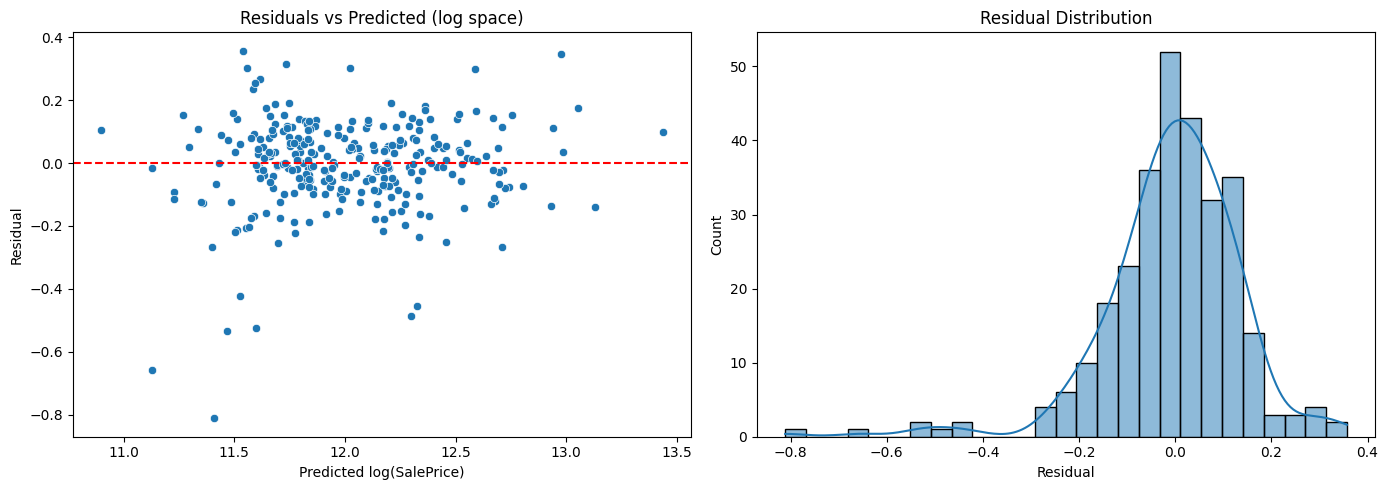

In [29]:
# Evaluate the baseline in log space and inspect residual structure
from sklearn.metrics import root_mean_squared_error

y_val_pred = baseline_model.predict(X_val)
baseline_rmse = root_mean_squared_error(y_val, y_val_pred)
residuals = y_val - y_val_pred

print(f'Baseline validation RMSE (log space): {baseline_rmse:.5f}')
print(f'Residual mean: {residuals.mean():.5f}')
print(f'Residual standard deviation: {residuals.std():.5f}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.scatterplot(x=y_val_pred, y=residuals, ax=axes[0])
axes[0].axhline(0, color='red', linestyle='--')
axes[0].set_title('Residuals vs Predicted (log space)')
axes[0].set_xlabel('Predicted log(SalePrice)')
axes[0].set_ylabel('Residual')

sns.histplot(residuals, kde=True, ax=axes[1])
axes[1].set_title('Residual Distribution')
axes[1].set_xlabel('Residual')

plt.tight_layout()
plt.show()

In [ ]:
# Hint-only scaffold for the next step: compare regularized linear models with the same preprocessor
# 1. Import Ridge, Lasso, and ElasticNet.
# 2. Reuse baseline_preprocessor so the preprocessing stays identical.
# 3. Create one Pipeline per model.
# 4. Fit each model on X_train, y_train.
# 5. Predict on X_val and compute RMSE in log space.
# 6. Compare scores in a small summary table.
# 7. Check whether regularization reduces the negative residual tail.

# Example structure to build yourself:
# ridge_model = Pipeline([...])
# lasso_model = Pipeline([...])
# elastic_model = Pipeline([...])